In [1]:
from src.dm import DataModule

dm = DataModule(batch_size=4, num_workers=0, pin_memory=False)

dm.setup()

In [2]:
dm.test_df

,image,AOD
0,data/test_images/test_1.tif,1.442470
1,data/test_images/test_2.tif,0.910374
2,data/test_images/test_3.tif,0.500745
3,data/test_images/test_4.tif,0.999882
4,data/test_images/test_5.tif,1.668206
...,...,...
1484,data/test_images/test_1485.tif,1.597977
1485,data/test_images/test_1486.tif,1.819262
1486,data/test_images/test_1487.tif,1.334963
1487,data/test_images/test_1488.tif,0.231196


In [3]:
import os

os.listdir('checkpoints')

['baseline-val_metric=0.83894-epoch=99.ckpt',
 'lrsch-val_metric=0.89440-epoch=492.ckpt',
 'da-epoch=199.ckpt',
 'lrsch-epoch=199.ckpt',
 'lrsch-epoch=499-v1.ckpt',
 'lrsch-val_metric=0.94095-epoch=461.ckpt',
 'baseline-epoch=199.ckpt',
 'baseline-epoch=99.ckpt',
 'baseline-val_metric=0.92066-epoch=199.ckpt',
 'lrsch-val_metric=0.85539-epoch=9.ckpt',
 'lrsch-val_metric=0.86534-epoch=96.ckpt',
 'lrsch-epoch=1.ckpt',
 'da-epoch=99.ckpt',
 'lrsch-val_metric=0.56465-epoch=1.ckpt',
 'lrsch-epoch=499.ckpt',
 'ft-val_metric=0.84048-epoch=99.ckpt',
 'da-val_metric=0.82154-epoch=99.ckpt',
 'lrsch-epoch=9.ckpt',
 'lrsch-epoch=99.ckpt',
 'ft-epoch=99.ckpt',
 'lrsch-val_metric=0.92938-epoch=188.ckpt',
 'da-val_metric=0.91423-epoch=199.ckpt']

In [4]:
import torch 
from src.module import Module

name = "lrsch-val_metric=0.94095-epoch=461.ckpt"
checkpoint = f'./checkpoints/{name}'


checkpoint = torch.load(checkpoint, map_location='cpu')
state_dict = checkpoint['state_dict']
module = Module()
module.load_state_dict(state_dict)

/home/juan/miniconda3/envs/peo/lib/python3.8/site-packages/torchvision/datapoints/__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/pytorch/vision/issues/7319 to learn more about the APIs that we suspect might involve future changes. You can silence this warning by calling torchvision.disable_beta_transforms_warning().
  warnings.warn(_BETA_TRANSFORMS_WARNING)
/home/juan/miniconda3/envs/peo/lib/python3.8/site-packages/torchvision/transforms/v2/__init__.py:54: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedba

<All keys matched successfully>

In [5]:
checkpoint['hyper_parameters']

{'freeze': True,
 'optimizer': 'Adam',
 'optimizer_params': {'lr': 0.0003},
 'ckpt_path': None,
 'load_from_checkpoint': None,
 'trainer': {'accelerator': 'cuda',
  'devices': 1,
  'max_epochs': 500,
  'logger': <lightning.pytorch.loggers.wandb.WandbLogger at 0x795ece139610>,
  'enable_checkpointing': True,
  'overfit_batches': 0,
  'precision': '16-mixed',
  'deterministic': True,
  'callbacks': [<lightning.pytorch.callbacks.model_checkpoint.ModelCheckpoint at 0x795ece139670>,
   <lightning.pytorch.callbacks.model_summary.ModelSummary at 0x795e87d62190>]},
 'datamodule': {'batch_size': 64,
  'num_workers': 20,
  'pin_memory': True,
  'train_trans': {},
  'val_size': 0.2,
  'bands': [2, 3, 4, 5, 6, 7, 8, 9, 11, 12]},
 'scheduler': 'OneCycleLR',
 'scheduler_params': {'max_lr': 0.001,
  'total_steps': 500,
  'pct_start': 0.03,
  'final_div_factor': 10,
  'verbose': True}}

In [25]:
class Identity:
    def __call__(self, x):
        return x

class Rot90:
    def __init__(self, axes=(2, 3)):
        self.axes = axes
    def __call__(self, x):
        return torch.rot90(x, 1, self.axes)

class Rot180:
    def __init__(self, axes=(2, 3)):
        self.axes = axes
    def __call__(self, x):
        return torch.rot90(x, 2, self.axes)

class Rot270:
    def __init__(self, axes=(2, 3)):
        self.axes = axes
    def __call__(self, x):
        return torch.rot90(x, 3, self.axes)

class Flip:
    def __init__(self, axis=2):
        self.axis = axis
    def __call__(self, x):
        return torch.flip(x, [self.axis])

class Transpose:
    def __init__(self, axes=(2, 3)):
        self.axes = axes
    def __call__(self, x):
        return torch.transpose(x, self.axes[0], self.axes[1])

trans = [
    (Identity(), Identity()),
    (Rot90(), Rot270()),
    (Rot180(), Rot180()),
    (Rot270(), Rot90()),
    (Flip(2), Flip(2)),
    (Flip(3), Flip(3)),
    (Transpose(), Transpose()),
]

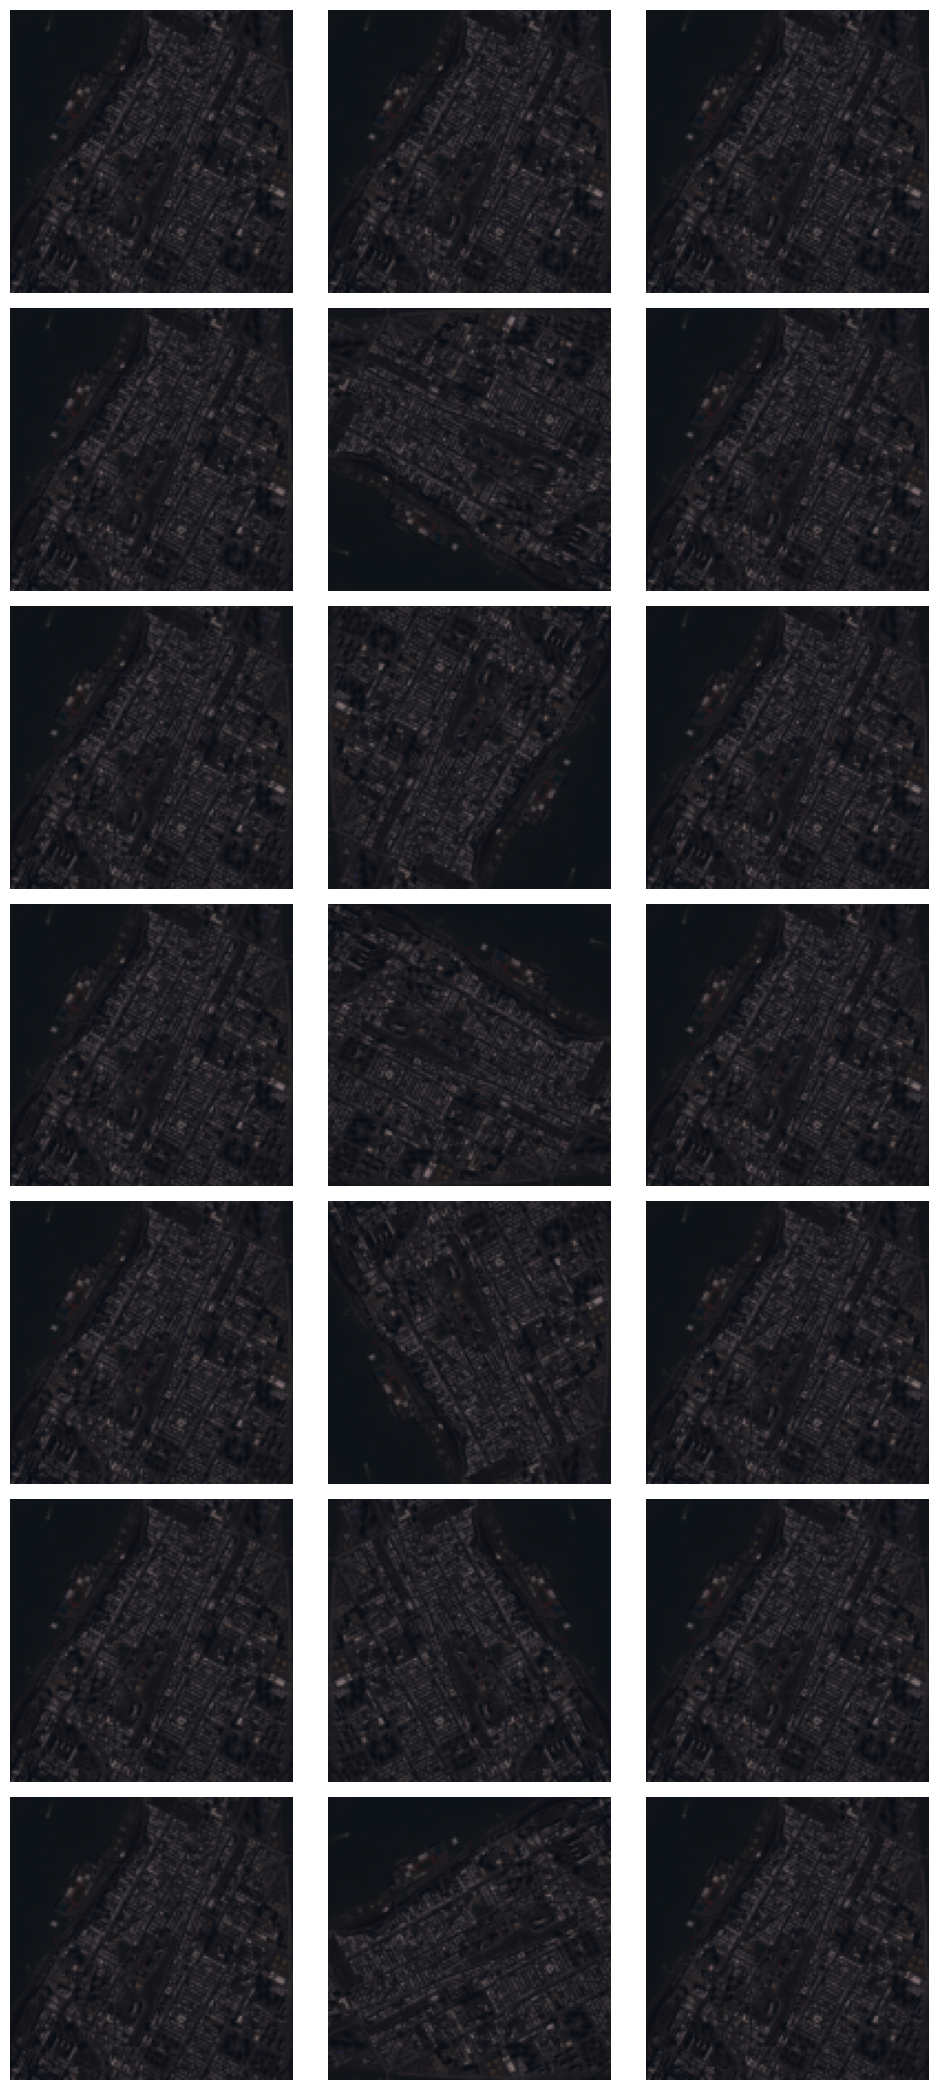

In [12]:
import torch 
import matplotlib.pyplot as plt 

dl = dm.train_dataloader(batch_size=1)
datacube, _ = next(iter(dl))

def get_image(x):
    return x[0][(2,1,0), ...].permute(1,2,0)

fig, ax = plt.subplots(len(trans), 3, figsize=(10, 3*len(trans)))
for i, (t1, t2) in enumerate(trans):
    x = datacube['pixels']
    ax[i, 0].imshow(get_image(x))
    ax[i, 0].axis('off')
    ax[i, 1].imshow(get_image(t1(x)))
    ax[i, 1].axis('off')
    ax[i, 2].imshow(get_image(t2(t1(x))))
    ax[i, 2].axis('off')
plt.tight_layout()
plt.show()

In [45]:
from tqdm import tqdm 
import torchmetrics

trans = [
    Identity(),
    Rot90(), 
    Rot180(), 
    Rot270(), 
    Flip(2), 
    Flip(3), 
    Transpose()
]

device = "cuda:1"
module.to(device)
module.eval()

dm = DataModule(batch_size=32, num_workers=8, pin_memory=True, val_size=0.2)
dm.setup()
dl = dm.val_dataloader(batch_size=4, shuffle=False)
metric = torchmetrics.PearsonCorrCoef()
pgbar = tqdm(dl, total=len(dl), leave=True)
cumulative_metric = 0.0
num_batches = 0
for batch in pgbar:
    x, y = batch
    x = {k: v.to(device) for k, v in x.items()}
    x0 = x['pixels'].clone()
    preds = []
    for t in trans:
        x['pixels'] = t(x0)
        preds.append(module(x))
    preds = torch.stack(preds).mean(0).cpu()
    metric.update(preds, y)

final_metric = metric.compute().item()
print(f"Final Metric: {final_metric:.5f}")

100%|██████████| 224/224 [00:13<00:00, 16.68it/s]

Final Metric: 0.92884


In [26]:
from tqdm import tqdm

trans = [
    Identity(),
    Rot90(), 
    Rot180(), 
    Rot270(), 
    Flip(2), 
    Flip(3), 
    Transpose()
]

device = "cuda:1"
module.to(device)
module.eval()


preds = []
for batch in tqdm(dm.test_dataloader()):
    dict_of_tensors, _ = batch
    dict_of_tensors = {k: v.to(device) for k, v in dict_of_tensors.items()}
    x0 = dict_of_tensors['pixels'].clone()
    _preds = []
    with torch.no_grad():
        for t in trans:
            dict_of_tensors['pixels'] = t(x0)
            _preds.append(module(dict_of_tensors))
    output = torch.stack(_preds).mean(0).cpu()
    output = output * dm.aod_stats[1] + dm.aod_stats[0] 
    preds += output.cpu().tolist()

100%|██████████| 47/47 [00:30<00:00,  1.55it/s]


In [27]:
dm.test_df['AOD'] = preds
dm.test_df.image = dm.test_df.image.apply(lambda x: x.split('/')[-1])

dm.test_df

,image,AOD
0,test_1.tif,0.093511
1,test_2.tif,0.259289
2,test_3.tif,0.236885
3,test_4.tif,0.102981
4,test_5.tif,0.092082
...,...,...
1484,test_1485.tif,0.047147
1485,test_1486.tif,0.139966
1486,test_1487.tif,0.001303
1487,test_1488.tif,0.189315


In [28]:
dm.test_df.to_csv('submission.csv', index=False, header=False)